In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Model training notebook started.")

Model training notebook started.


In [50]:
PROJECT_ROOT = Path.cwd().parents[0]

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Model directory:", MODEL_DIR)

Project root: c:\Users\Devanshu Lingwal\OneDrive\Desktop\Personal\smart-classroom-automation
Processed data: c:\Users\Devanshu Lingwal\OneDrive\Desktop\Personal\smart-classroom-automation\data\processed
Model directory: c:\Users\Devanshu Lingwal\OneDrive\Desktop\Personal\smart-classroom-automation\models


In [51]:
X = pd.read_csv(
    PROCESSED_DIR
    / "model_features.csv"
)

y = pd.read_csv(
    PROCESSED_DIR
    / "model_target.csv"
).squeeze()

print("Model-ready data loaded.")

print()
print("X shape:", X.shape)

print("y shape:", y.shape)

print()
print("Number of features:", X.shape[1])

Model-ready data loaded.

X shape: (2024, 18)
y shape: (2024,)

Number of features: 18


In [52]:
print("Feature columns:")

for column in X.columns:
    print("-", column)

print()
print("Target:")
print(y.name)

print()
print("First 5 feature rows:")
display(X.head())

print()
print("First 5 target values:")
display(y.head())

Feature columns:
- people_count
- duration_seconds
- power_watts
- hour
- minute
- day_of_week
- day_of_month
- month
- is_weekend
- high_occupancy
- long_session
- zone_name_Zone 2
- appliance_light
- time_period_Evening
- time_period_Morning
- time_period_Night
- occupancy_level_High
- occupancy_level_Low

Target:
energy_wh

First 5 feature rows:


,people_count,duration_seconds,power_watts,hour,minute,day_of_week,day_of_month,month,is_weekend,high_occupancy,long_session,zone_name_Zone 2,appliance_light,time_period_Evening,time_period_Morning,time_period_Night,occupancy_level_High,occupancy_level_Low
0,-1.086680,-0.191419,-1.013931,-1.337883,0.471676,-0.984868,1.461472,6.145295,-0.624588,-0.657581,0.393182,-0.997040,1.013931,-0.442166,-0.631471,1.391974,-0.657581,1.015937
1,-1.086680,-0.191419,0.986260,-1.337883,0.471676,-0.984868,1.461472,6.145295,-0.624588,-0.657581,0.393182,-0.997040,-0.986260,-0.442166,-0.631471,1.391974,-0.657581,1.015937
2,-1.268889,-1.387286,-1.013931,-1.337883,0.759940,-0.984868,1.461472,6.145295,-0.624588,-0.657581,-2.543351,1.002969,1.013931,-0.442166,-0.631471,1.391974,-0.657581,-0.984313
3,-1.268889,-1.444655,0.986260,-1.337883,0.759940,-0.984868,1.461472,6.145295,-0.624588,-0.657581,-2.543351,1.002969,-0.986260,-0.442166,-0.631471,1.391974,-0.657581,-0.984313
4,-1.268889,-1.415627,-1.013931,-1.337883,0.817592,-0.984868,1.461472,6.145295,-0.624588,-0.657581,-2.543351,-0.997040,1.013931,-0.442166,-0.631471,1.391974,-0.657581,-0.984313



First 5 target values:


0    0.666667
1    1.250000
2    0.198406
3    0.329891
4    0.187308
Name: energy_wh, dtype: float64

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train/Test split completed.")

print()
print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print()
print("Training targets:", y_train.shape)
print("Testing targets :", y_test.shape)

Train/Test split completed.

Training features: (1619, 18)
Testing features : (405, 18)

Training targets: (1619,)
Testing targets : (405,)


In [54]:
model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [55]:
model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [56]:
y_pred = model.predict(
    X_test
)

print("Predictions generated.")

print()
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated.

First 10 predictions:
[0.6653164  2.44594815 1.35285    2.89983335 0.7539277  0.6783112
 0.38701675 0.71928135 2.65919815 0.7300946 ]


In [57]:
mae = mean_absolute_error(
y_test,
y_pred
)

print("MAE:", mae)

MAE: 0.003587821336761635


In [58]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MSE : 0.00015186285013550722
RMSE: 0.012323264589203107
R²  : 0.9996747066260661


In [59]:
print("========================================")
print("MODEL EVALUATION")
print("========================================")

print()

print(f"MAE  : {mae:.4f} Wh")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} Wh")
print(f"R²   : {r2:.4f}")

MODEL EVALUATION

MAE  : 0.0036 Wh
MSE  : 0.0002
RMSE : 0.0123 Wh
R²   : 0.9997


In [60]:
comparison = pd.DataFrame({
    "Actual Energy (Wh)": y_test.values,
    "Predicted Energy (Wh)": y_pred
})

comparison.head(20)

,Actual Energy (Wh),Predicted Energy (Wh)
0,0.663000,0.665316
1,2.450833,2.445948
2,1.348778,1.352850
3,2.923542,2.899833
4,0.754444,0.753928
5,0.681111,0.678311
6,0.386556,0.387017
7,0.719792,0.719281
8,2.660208,2.659198
9,0.730000,0.730095


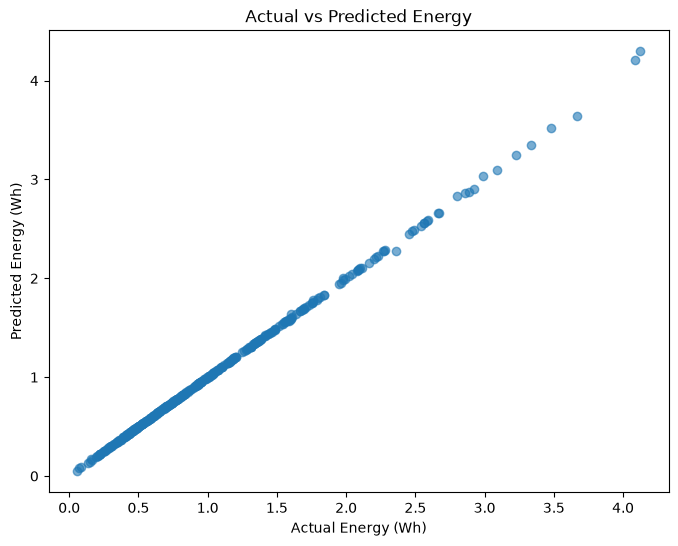

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Energy (Wh)")
plt.ylabel("Predicted Energy (Wh)")
plt.title("Actual vs Predicted Energy")

plt.show()

In [62]:
residuals = (
    y_test.values - y_pred
)

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[-2.316400e-03  4.884850e-03 -4.072000e-03  2.370865e-02  5.163000e-04
  2.799800e-03 -4.607500e-04  5.106500e-04  1.009850e-03 -9.460000e-05]


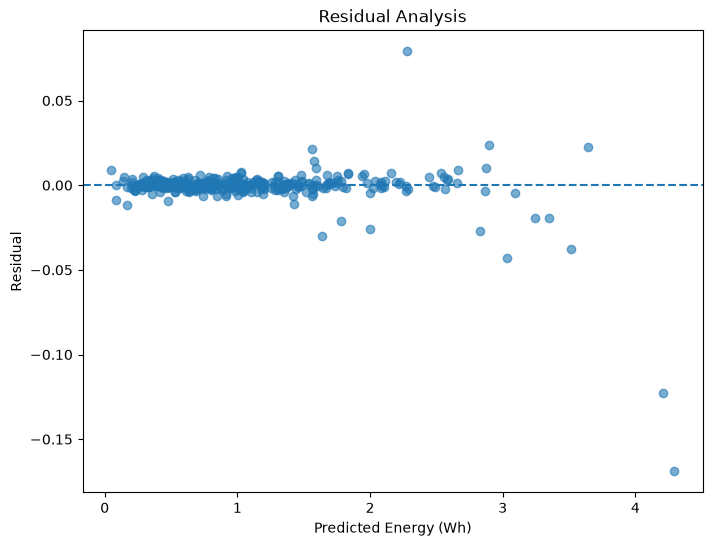

In [63]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Energy (Wh)")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

In [64]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
)

feature_importance

,feature,importance
1,duration_seconds,0.741914
12,appliance_light,0.166409
2,power_watts,0.090856
3,hour,0.000257
10,long_session,0.000152
0,people_count,0.000087
4,minute,0.000063
7,month,0.000052
15,time_period_Night,0.000050
6,day_of_month,0.000043


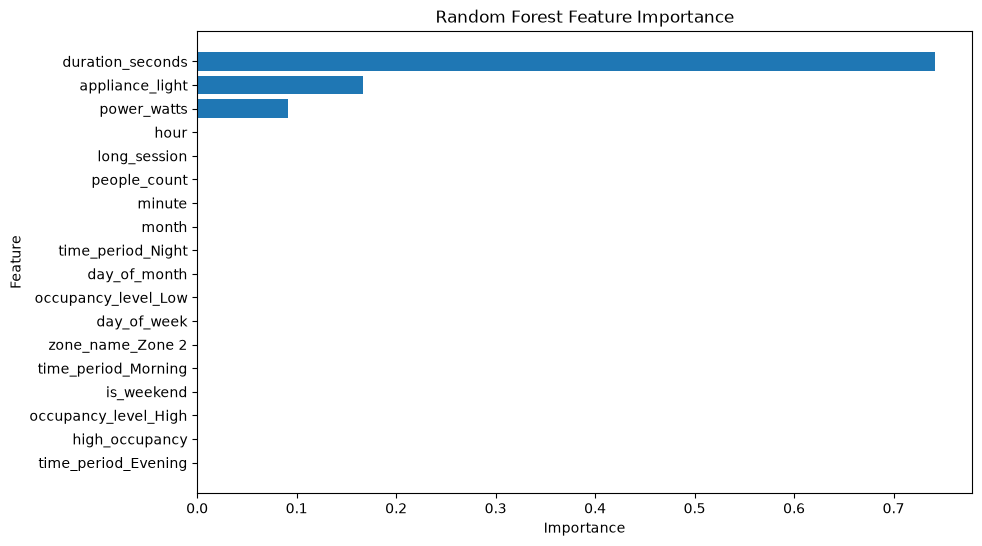

In [65]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [66]:
import joblib

MODEL_PATH = (
    MODEL_DIR
    / "energy_random_forest.pkl"
)

joblib.dump(
    model,
    MODEL_PATH
)

print("Random Forest model saved:")
print(MODEL_PATH)

Random Forest model saved:
c:\Users\Devanshu Lingwal\OneDrive\Desktop\Personal\smart-classroom-automation\models\energy_random_forest.pkl


In [67]:
loaded_model = joblib.load(
    MODEL_PATH
)

print("Saved model loaded successfully.")

test_predictions = loaded_model.predict(
    X_test
)

print()
print("Verification prediction:")
print(test_predictions[:5])

Saved model loaded successfully.

Verification prediction:
[0.6653164  2.44594815 1.35285    2.89983335 0.7539277 ]


In [68]:
print("========================================")
print("MODEL TRAINING COMPLETE")
print("========================================")

print()

print("Dataset rows :", len(X))
print("Features     :", X.shape[1])

print()

print(f"MAE  : {mae:.4f} Wh")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} Wh")
print(f"R²   : {r2:.4f}")

print()

print("Model:")
print(MODEL_PATH)

print()

print("Top features:")

print(
    feature_importance.head(5)
)

MODEL TRAINING COMPLETE

Dataset rows : 2024
Features     : 18

MAE  : 0.0036 Wh
MSE  : 0.0002
RMSE : 0.0123 Wh
R²   : 0.9997

Model:
c:\Users\Devanshu Lingwal\OneDrive\Desktop\Personal\smart-classroom-automation\models\energy_random_forest.pkl

Top features:
             feature  importance
1   duration_seconds    0.741914
12   appliance_light    0.166409
2        power_watts    0.090856
3               hour    0.000257
10      long_session    0.000152
